## Task 1 : Load and prepare data

Load and prepare data:
<li>Load the dog-cat-detection datasets</li>
<li>split the trainval set into a training and validation set. Use a stratified 80/20 split.</li>
<li>Resize the images in such a way that they have a fixed 112x112x3 format. Make sure the bounding boxes are transformed in a similar manner.</li>


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/dog-and-cat-detection")

print("Path to dataset files:", path)

Visualize cat-dog dataset

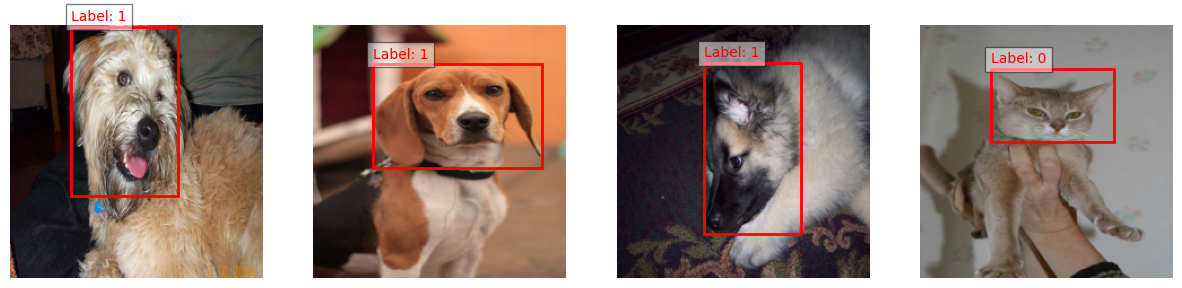

In [17]:
import os
import glob
import torch
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

INPUT_IMG_SZ = 224

IMG_DIR = os.path.join(path, "images")
ANNOTATION_DIR = os.path.join(path, "annotations")


class CatDogDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.ann_files = sorted(glob.glob(os.path.join(ann_dir, "*.xml")))
        self.label_map = {"cat": 0, "dog": 1}  # Label mapping

    def parse_annotation(self, ann_path):
        tree = ET.parse(ann_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)
        objects = []

        for obj in root.findall("object"):
            name = obj.find("name").text
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            label = self.label_map.get(name, -1)  # Default to -1 if unknown label
            objects.append({"label": label, "bbox": [xmin, ymin, xmax, ymax]})

        return width, height, objects

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        ann_path = self.ann_files[idx]

        image = Image.open(img_path).convert("RGB")
        width, height, objects = self.parse_annotation(ann_path)

        scaler_x = width / INPUT_IMG_SZ
        scaler_y = height / INPUT_IMG_SZ

        bboxes = []
        for obj in objects:
            xmin = obj['bbox'][0] / scaler_x
            ymin = obj['bbox'][1] / scaler_y
            xmax = obj['bbox'][2] / scaler_x
            ymax = obj['bbox'][3] / scaler_y
            bboxes.append([xmin, ymin, xmax, ymax])  # in your assignment 4, you need to convert bbox into [x, y, w, h] and value range [0, 1]

        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor([obj["label"] for obj in objects], dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, bboxes, labels


# Define transformations
transform = T.Compose([
    T.Resize((INPUT_IMG_SZ, INPUT_IMG_SZ)),
    T.ToTensor()
])

# Initialize dataset and dataloader
dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


# Function to visualize a batch
def visualize_batch(dataloader):
    images, bboxes, labels = next(iter(dataloader))
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

    if len(images) == 1:
        axes = [axes]

    for i, (img, bbox, label) in enumerate(zip(images, bboxes, labels)):
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)

        for box, lbl in zip(bbox, label):
            xmin, ymin, xmax, ymax = box.tolist()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='r', facecolor='none')
            axes[i].add_patch(rect)
            axes[i].text(xmin, ymin - 5, f'Label: {lbl.item()}', color='red', fontsize=10,
                         bbox=dict(facecolor='white', alpha=0.5))
        axes[i].axis('off')

    plt.show()


# Visualize a batch
visualize_batch(dataloader)


## Task 2 : Develop the architecture

<li> Your network contains the layers below. The output is similar to the YOLOv1 output, with a 7x7 spatial grid but with B=1 detections per cell, and only C=2 classes.</li>
<li>You can decide the type of pooling, activation functions, and whether or not to use dropout and batch normalization.</li>

Pay attention to the activation function of the output layer. At this point, we're not using non-maximum suppression. Your network should have approximately 1M parameters.

## Task 3 : Train your object detector model

<li>Use the dog-cat-detection train and val sets to train your network from scratch.</li>
<li>use early stopping on the loss of your val set. </li>
<li>Use the same five losses as in the original YOLOv1 paper, with the same weights. </li>
<li>You are free to choose your hyperparameters, including batch size, optimizer and learning rate.</li>

## Task 4 : Evaluate the performance of your trained model

<li>Report the mAP when changing the objectness threshold from 0 to 1.</li>
<li>Present a confusion matrix for the threshold setting for which mAP is maximal.</li>